Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


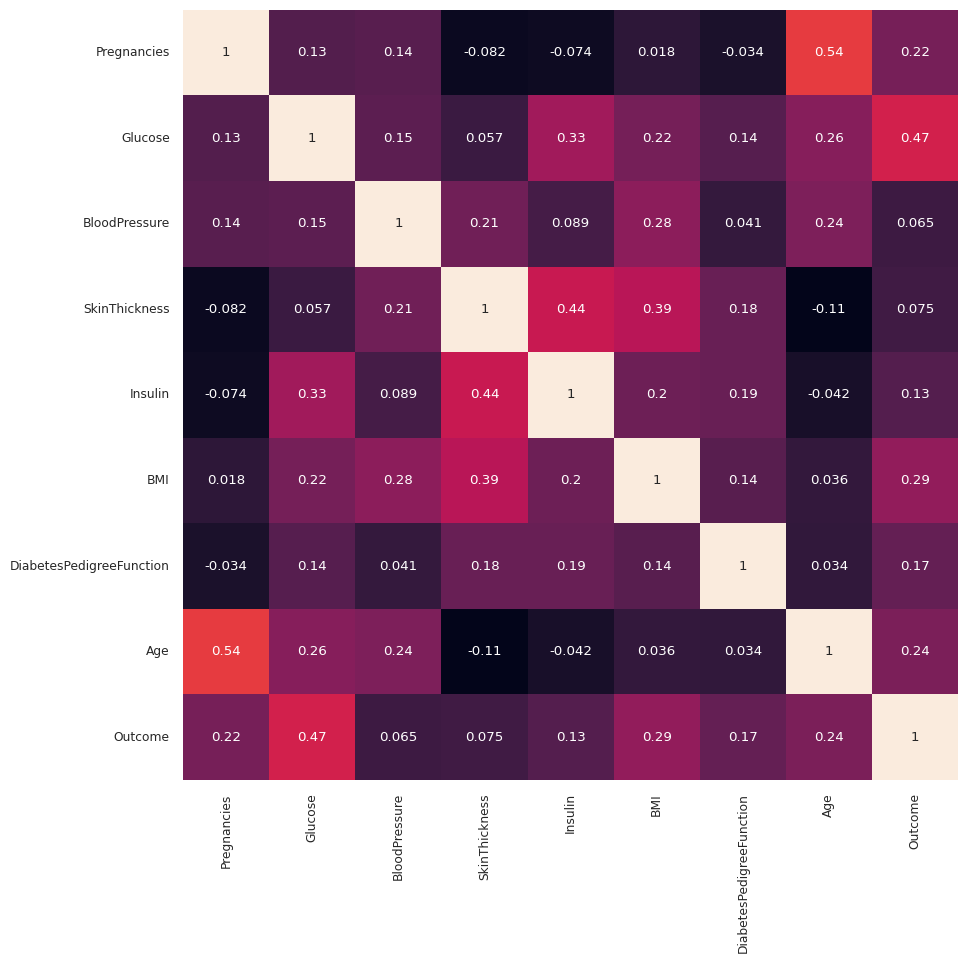

(614, 7) (614,) (154, 7) (154,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295 (5.06 KB)

 Trainable params: 1,295 (5.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 153.1780 - mse: 153.1780 - val_loss: 78.1201 - val_mse: 78.1201
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 70.4641 - mse: 70.4641 - val_loss: 73.4859 - val_mse: 73.4859
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 66.5351 - mse: 66.5351 - val_loss: 101.7940 - val_mse: 101.7940
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 68.7159 - mse: 68.7159 - val_loss: 84.1679 - val_mse: 84.1679
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 63.9914 - mse: 63.9914 - val_loss: 90.1314 - val_mse: 90.1314
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 63.0365 - mse: 63.0365 - val_loss: 66.6049 - val_mse: 66.6049
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 60.0492 - mse: 60.0492 - val_loss: 61.5929 - val_mse: 61.5929
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 57.1883 - mse: 57.1883 - val_loss: 91.9051 - val_mse: 91.9051
Epoch 9/100
20/20 ━━

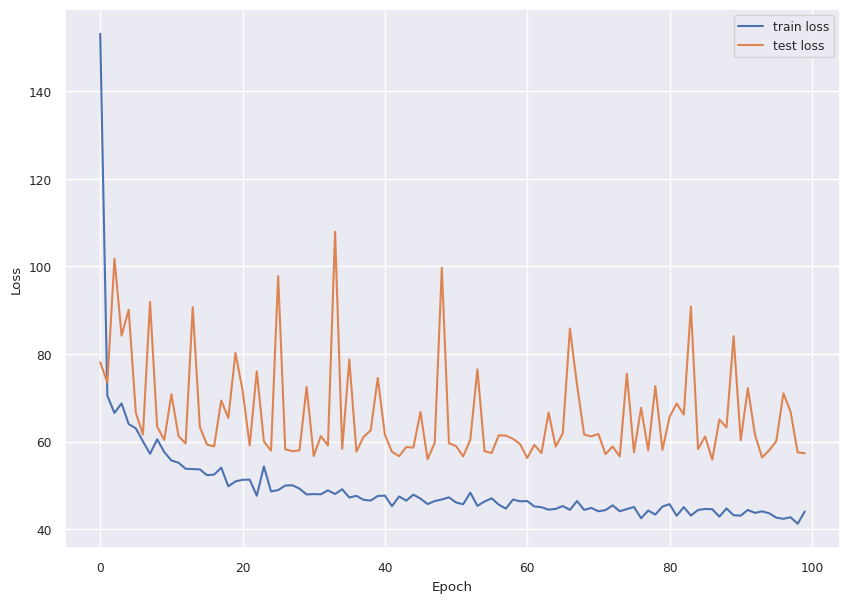

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 57.3249 - mse: 57.3249 


[57.324851989746094, 57.324851989746094]

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/diabetes.csv")

df_corr = df.corr()
plt.figure(figsize=(10, 10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

X = df.drop(['Outcome', 'BMI'], axis=1)
y = df['BMI']

X = X.values
y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

model = Sequential()
model.add(Dense(8, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='rmsprop', loss='mse', metrics=['mse'])

model.summary()

N_EPOCHS = 100

history = model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32, validation_data=(X_test, y_test))

y_pred = model.predict(X_test)

plt.figure(figsize=(10, 7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

model.evaluate(X_test, y_test)